**In diesem Notebook berechnen wir die Value at Risk und Expected Shortfall Werte.**

#Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import sys
sys.path.insert(0,'/content/drive/MyDrive/Masterthesis')
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load Historical Data


In [ ]:
import glob
import os
import re
path_bluechip = '/content/drive/MyDrive/Masterthesis/Data/Sequences/blueChip/samples'
path_crossAsset = '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples'
all_files = glob.glob(os.path.join(path_crossAsset, "synthetic_data_window_*.csv"))

def natural_sort_key(s):
    match = re.search(r'(\d+)\.csv$', s)
    if match:
        return int(match.group(1))
    return s
all_files.sort(key=natural_sort_key)
print(f"Files: {all_files}")

sequence_list = []
seq_length = 10 #

for f in all_files:
    df = pd.read_csv(f)
    print(f"Shape of {f}: {df.shape}")
    sequence_list.append(df)

data = pd.concat(sequence_list, ignore_index=True)
sequence_per_window = 10000

Found files: ['/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_1.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_2.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_3.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_4.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_5.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_6.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_7.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_8.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthetic_data_window_9.csv', '/content/drive/MyDrive/Masterthesis/Data/Sequences/crossAsset/samples/synthe

In [ ]:
num_points, num_variables = data.shape
num_sequences = (num_points // seq_length)//sequence_per_window

data_reshaped = data.to_numpy().reshape(num_sequences, seq_length, sequence_per_window, num_variables)
np.shape(data_reshaped)

(76, 10, 10000, 5)

In [ ]:
def portfolio_returns(returns, weights=None):

    returns = np.asarray(returns, dtype=float)

    returns = np.nan_to_num(returns)

    num_sequences, seq_length_minus_1, sequence_per_window, num_variables = returns.shape
    if weights is None:
        weights = np.ones(num_variables) / num_variables
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / np.sum(weights)


    port_ret = np.einsum('ijkl, l -> ijk', returns, weights)
    return port_ret



returns_data = portfolio_returns(data_reshaped)

In [ ]:
np.shape(returns_data)

(76, 10, 10000)

# Historical Method


In [ ]:
def historical_method(returns, confidence_level=0.975, es_confidence_level=0.975, path=None):


    num_sequences, sequence_length, sequence_per_window = returns.shape

    VaR_historical = []
    ES_historical = []

    for j in range(num_sequences):
        for i in range(sequence_length):
          window_returns = returns[j, i, :].flatten()

          if len(window_returns) > 0:
              # VaR
              var = np.percentile(window_returns, (1 - confidence_level) * 100)
              VaR_historical.append(var)

              # ES
              var_for_es = np.percentile(window_returns, (1 - es_confidence_level) * 100)
              losses_worse_than_var_es = window_returns[window_returns < var_for_es]

              if len(losses_worse_than_var_es) > 0:
                  es = losses_worse_than_var_es.mean()
                  ES_historical.append(es)
              else:
                  ES_historical.append(np.nan)
          else:
              VaR_historical.append(np.nan)
              ES_historical.append(np.nan)
              continue
    #Letzte 4 tage braucht man nicht
    VaR_array = np.array(VaR_historical)[:-4]
    ES_array = np.array(ES_historical)[:-4]


    if path is not None:
        df_output = pd.DataFrame({
            'VaR': VaR_array,
            'ES': ES_array
        })

        df_output.to_csv(f"{path}crossAsset_Diffusion.csv", index=False)

    return VaR_array, ES_array

# Save VaR and ES


In [ ]:
'''portfolios = {
    "bluechip": returns_bluechip,
}
save_path_base = "/content/drive/MyDrive/Masterthesis/Data/VaR_and_ES"

for name, returns in portfolios.items():
    print(f"Calculating VaR and ES for {name} portfolio...")

    historical_method(returns, path=f"{save_path_base}/{name}")
    variance_covariance_method(returns, path=f"{save_path_base}/{name}")
    monte_carlo_method(returns, path=f"{save_path_base}/{name}")


print("Calculations complete and results saved.")'''

'portfolios = {\n    "bluechip": returns_bluechip,\n}\nsave_path_base = "/content/drive/MyDrive/Masterthesis/Data/VaR_and_ES"\n\nfor name, returns in portfolios.items():\n    print(f"Calculating VaR and ES for {name} portfolio...")\n\n    historical_method(returns, path=f"{save_path_base}/{name}")\n    variance_covariance_method(returns, path=f"{save_path_base}/{name}")\n    monte_carlo_method(returns, path=f"{save_path_base}/{name}")\n\n\nprint("Calculations complete and results saved.")'

# Test


In [ ]:
path_bluechip = "/content/drive/MyDrive/Masterthesis/Data/Datasets/bluechip_sp500.csv"
path_crossAsset = "/content/drive/MyDrive/Masterthesis/Data/Datasets/crossAsset_portfolio.csv"


df_data = pd.read_csv(path_crossAsset)

def normal_portfolio_returns(returns, weights=None):
    returns = np.asarray(returns, dtype=float)
    returns = np.nan_to_num(returns)

    T, N = returns.shape
    if weights is None:
        weights = np.ones(N) / N
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / np.sum(weights)

    port_ret = returns @ weights
    return port_ret

normal_returns_data = normal_portfolio_returns(df_data)


Number of Historical VaR exceedances: 17


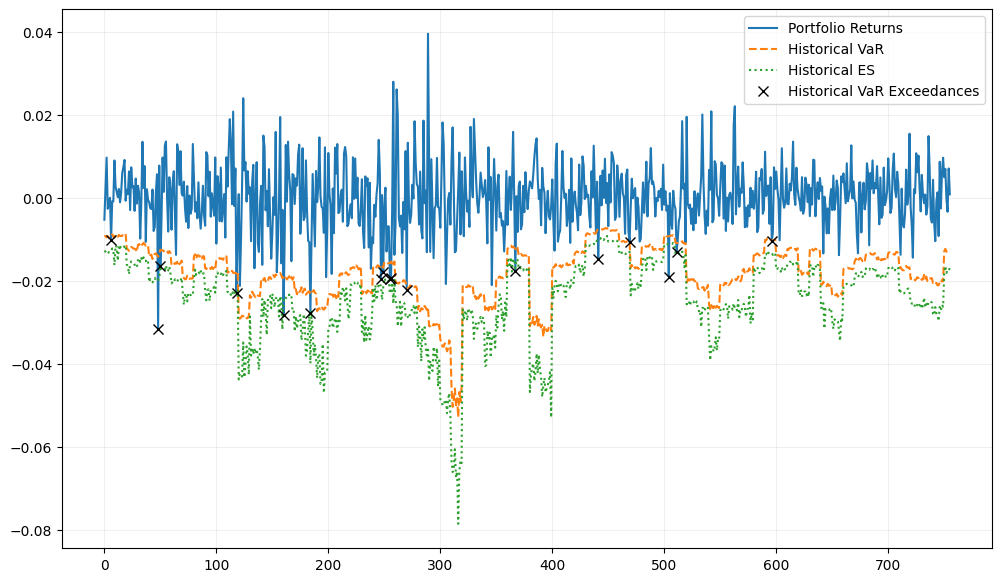

In [ ]:
crossAsset_train_length = 5298
bluechip_train_length = 4564
train_length = crossAsset_train_length

hist = historical_method(returns_data, path='/content/drive/MyDrive/Masterthesis/Data/VaR_and_ES/')

returns = normal_returns_data

plot_length = len(hist[0])

plt.figure(figsize=(12, 7))
plt.plot(range(plot_length), returns[train_length:train_length +plot_length ], label='Portfolio Returns')
plt.plot(range(plot_length), hist[0], label='Historical VaR', linestyle='--')
plt.plot(range(plot_length), hist[1], label='Historical ES', linestyle=':')

exceedances_historical_var = returns[train_length:train_length+plot_length] < hist[0]
plt.plot(np.where(exceedances_historical_var)[0], returns[train_length:train_length+ plot_length][exceedances_historical_var], 'kx', markersize=7, label='Historical VaR Exceedances')
print(f"Number of Historical VaR exceedances: {np.sum(exceedances_historical_var)}")

plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

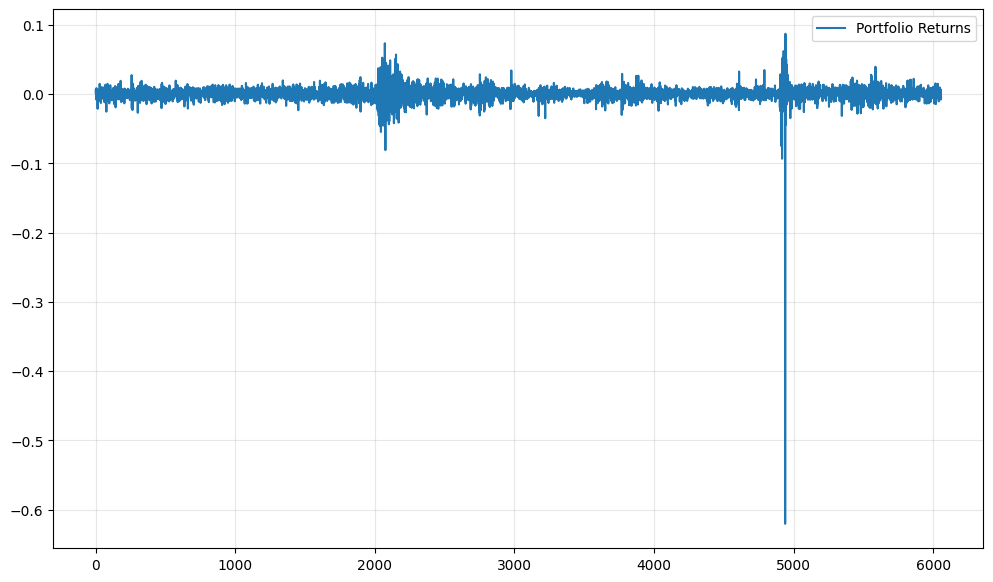

In [ ]:
returns = normal_returns_data

plot_length = len(hist[0])

plt.figure(figsize=(12, 7))
plt.plot(range(len(returns)), returns[:], label='Portfolio Returns')



plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

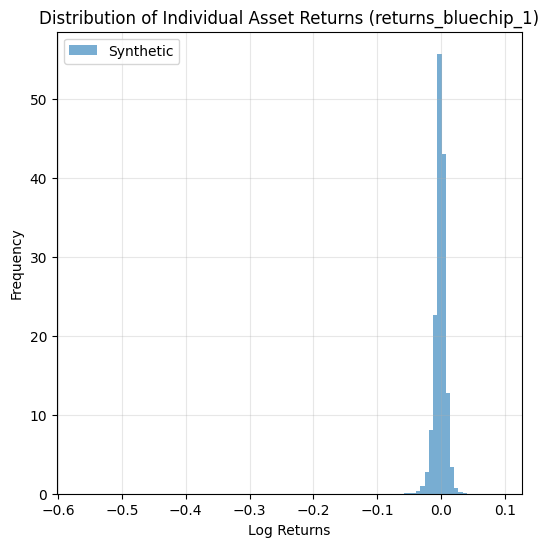

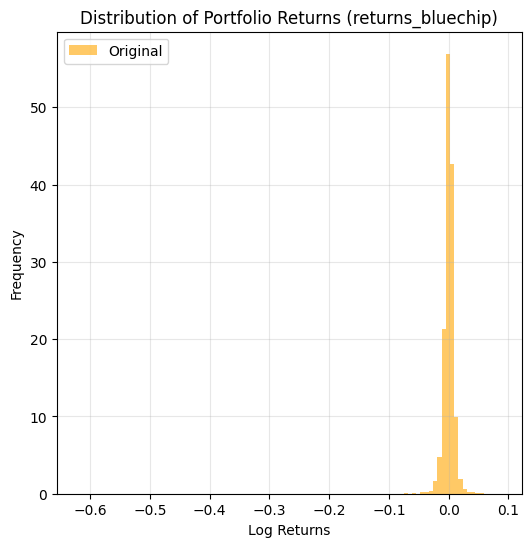

In [ ]:
plt.figure(figsize=(6, 6))
plt.hist(returns_data[:,:,:].flatten(), bins=100, density=True, alpha=0.6, label='Synthetic')
plt.title('Distribution of Individual Asset Returns (returns_bluechip_1)')
plt.xlabel('Log Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.hist(normal_returns_data.flatten(), bins=100, density=True, alpha=0.6, color='orange', label='Original')
plt.title('Distribution of Portfolio Returns (returns_bluechip)')
plt.xlabel('Log Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (760,) and (756,)

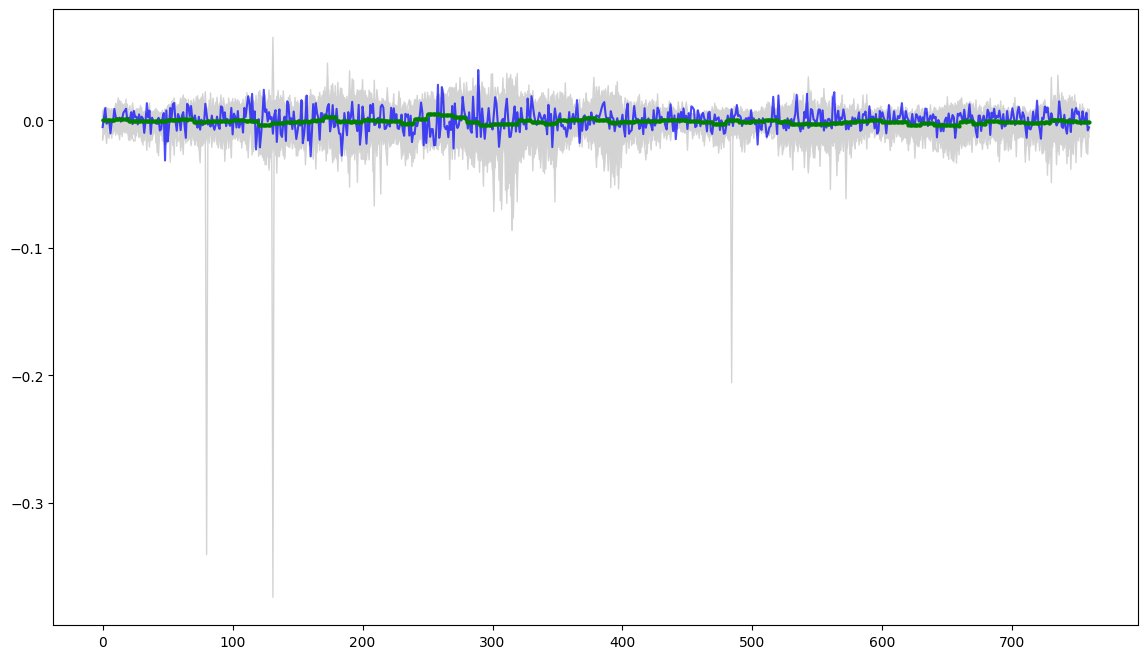

In [ ]:
generated_returns_flat_for_windows = returns_data.reshape(-1, sequence_per_window)
generated_median_returns = np.median(generated_returns_flat_for_windows, axis=1)
plot_length = len(generated_median_returns)

real_returns_segment = normal_returns_data[train_length : train_length + plot_length]

plt.figure(figsize=(14, 8))

num_examples_to_plot =50
random_sample_indices = np.random.choice(sequence_per_window, num_examples_to_plot, replace=False)

for i, sample_idx in enumerate(random_sample_indices):
    plt.plot(range(plot_length), generated_returns_flat_for_windows[:, sample_idx],
             color='lightgray', alpha=1, linestyle='-', linewidth=1,
             label=f'Generated Sequence Sample {i+1}' if i == 0 else "")

plt.plot(range(plot_length), real_returns_segment, label='Real Portfolio Returns', color='blue', alpha=0.7)
plt.plot(range(plot_length), generated_median_returns, label='Generated Median Returns', color='green', linestyle='-', marker='.', markersize=4)
plt.plot(range(plot_length), hist[0], label='Generated Historical VaR (95%)', linestyle='--', color='red')
plt.plot(range(plot_length), hist[1], label='Generated Historical ES (97.5%)', linestyle=':', color='purple')

exceedances_historical_var = real_returns_segment < hist[0]
exceedances_historical_es = real_returns_segment < hist[1]

plt.scatter(np.where(exceedances_historical_var)[0], real_returns_segment[exceedances_historical_var],
            color='red', marker='x', s=100, zorder=5, label='Real Returns < Generated VaR Exceedance')
plt.scatter(np.where(exceedances_historical_es)[0], real_returns_segment[exceedances_historical_es],
            color='purple', marker='o', s=50, zorder=5, label='Real Returns < Generated ES Exceedance')

print(f"Number of Real Returns < Generated Historical VaR exceedances: {np.sum(exceedances_historical_var)}")
print(f"Number of Real Returns < Generated Historical ES exceedances: {np.sum(exceedances_historical_es)}")

plt.title('Comparison of Real vs. Generated Portfolio Returns, VaR, and ES')
plt.xlabel('Time Window Index (each representing a window for VaR/ES calculation)')
plt.ylabel('Returns / VaR / ES')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()